In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 10.7 MB/s eta 0:00:00


Dataset not found locally -- fetching it from Google Drive automatically...


Downloading...
From: https://drive.google.com/uc?id=1iVq3qa_xrTHb422iZmxqrK1AS8E2h0La
To: /content/dataset_download.zip
100%|██████████| 6.40M/6.40M [00:00<00:00, 30.2MB/s]


Computing SHA256 checksum ...
SHA256: 7e70aedcd900e5e7c4e0b7993dc7d33c736a4eaeeb239296382a768afdb2cb48
No EXPECTED_SHA256 set yet -- skipping verification.
Tip: paste the checksum above into EXPECTED_SHA256 in this file so future downloads are automatically verified.
Extracting dataset ...

Done. Dataset is ready in ./dataset/
Checksum recorded in dataset/CHECKSUM.sha256

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=Fal

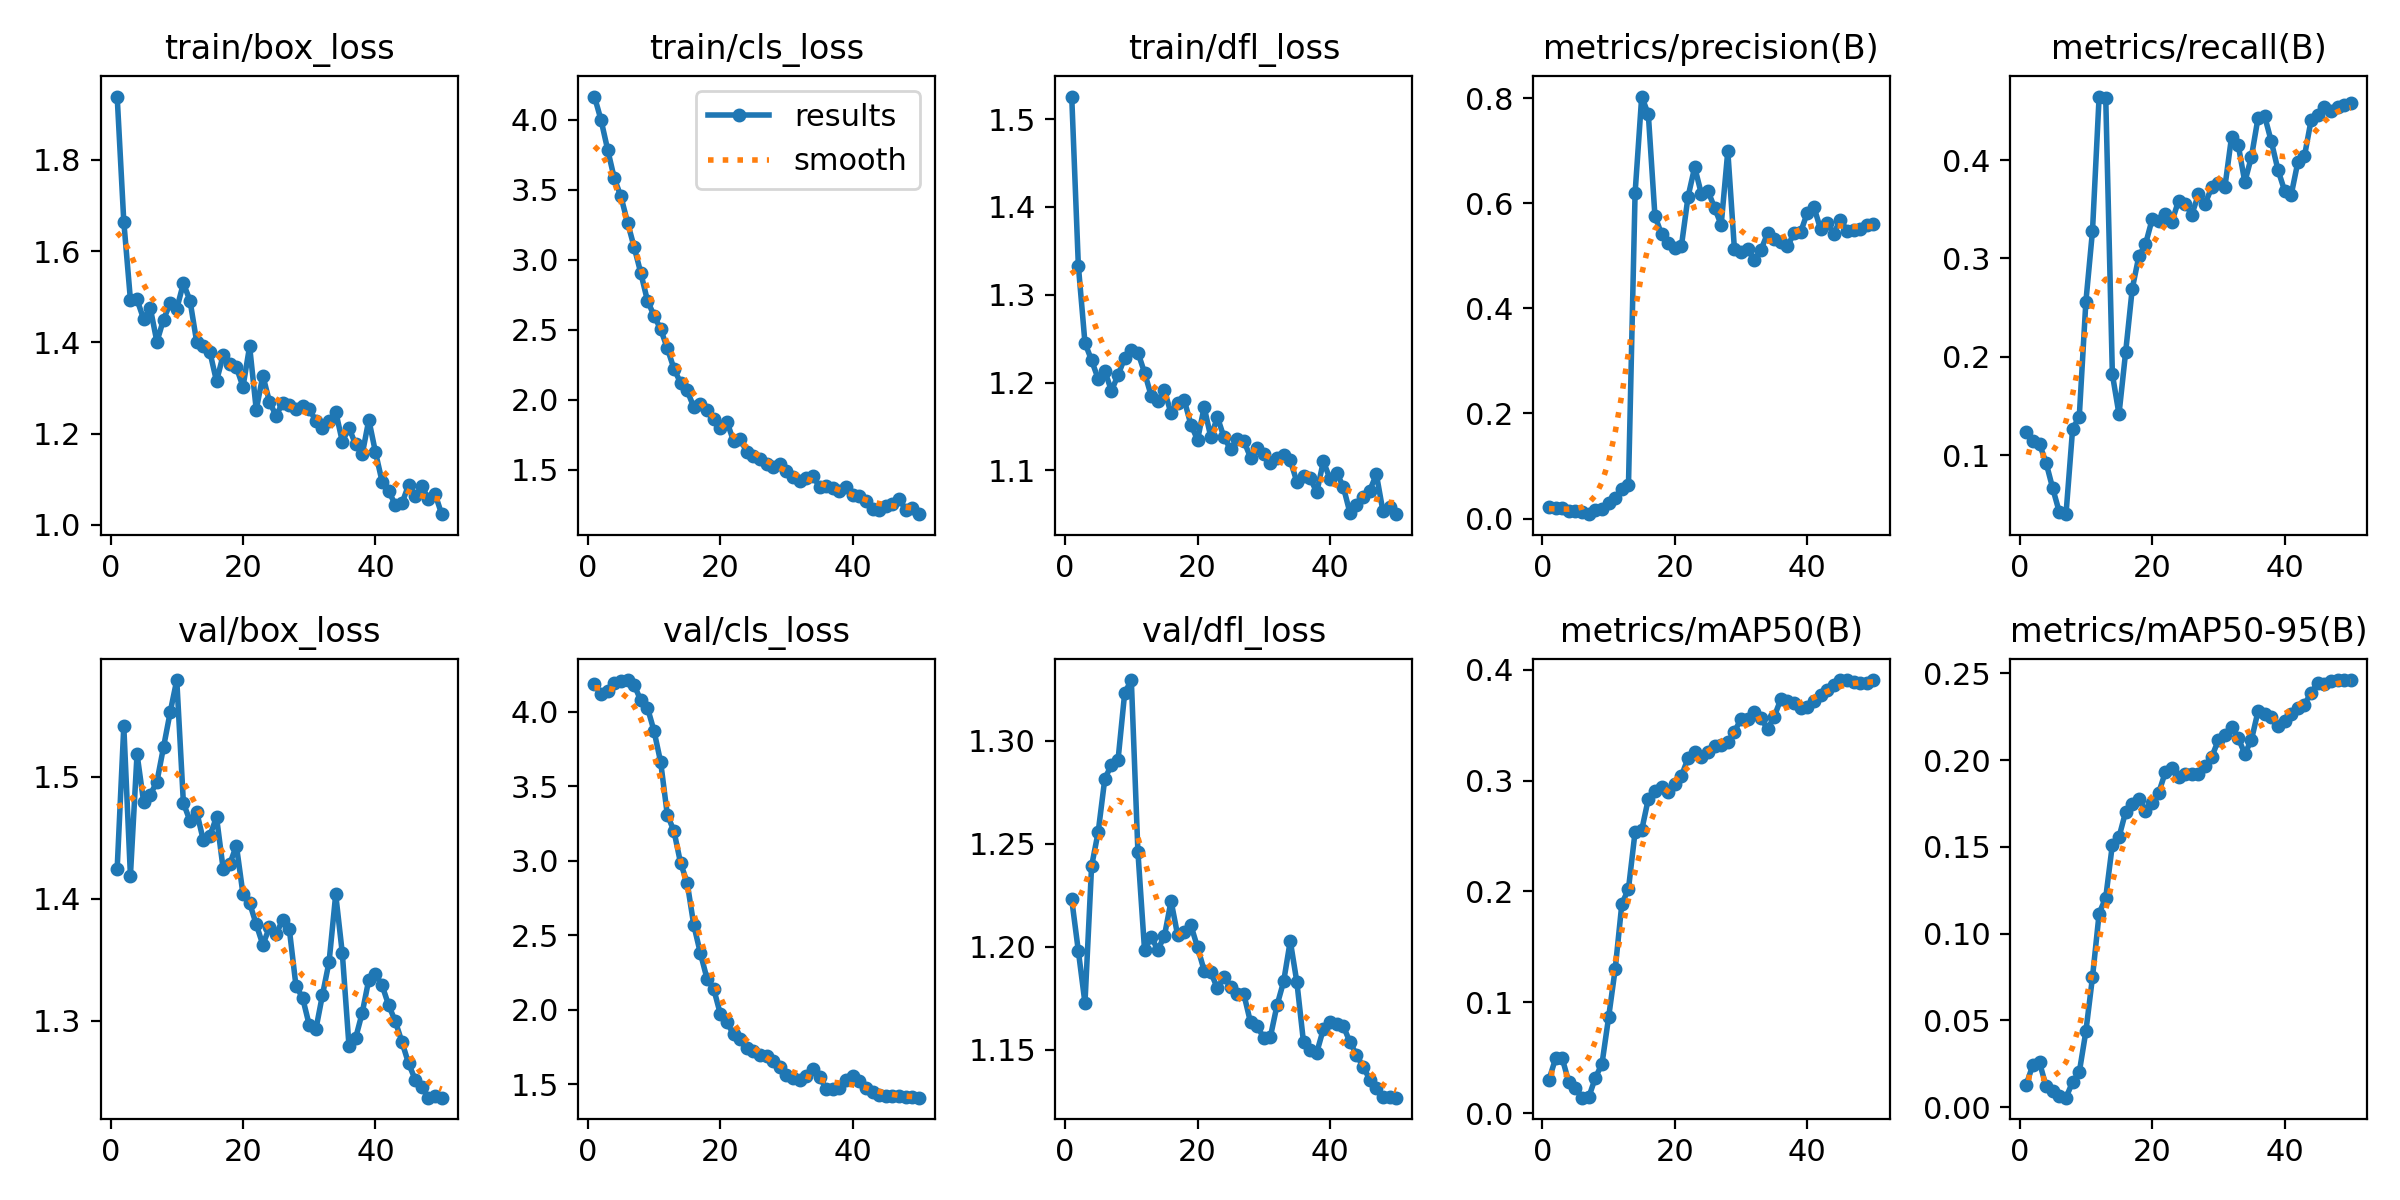


Example validation predictions (val_batch0_pred.jpg):


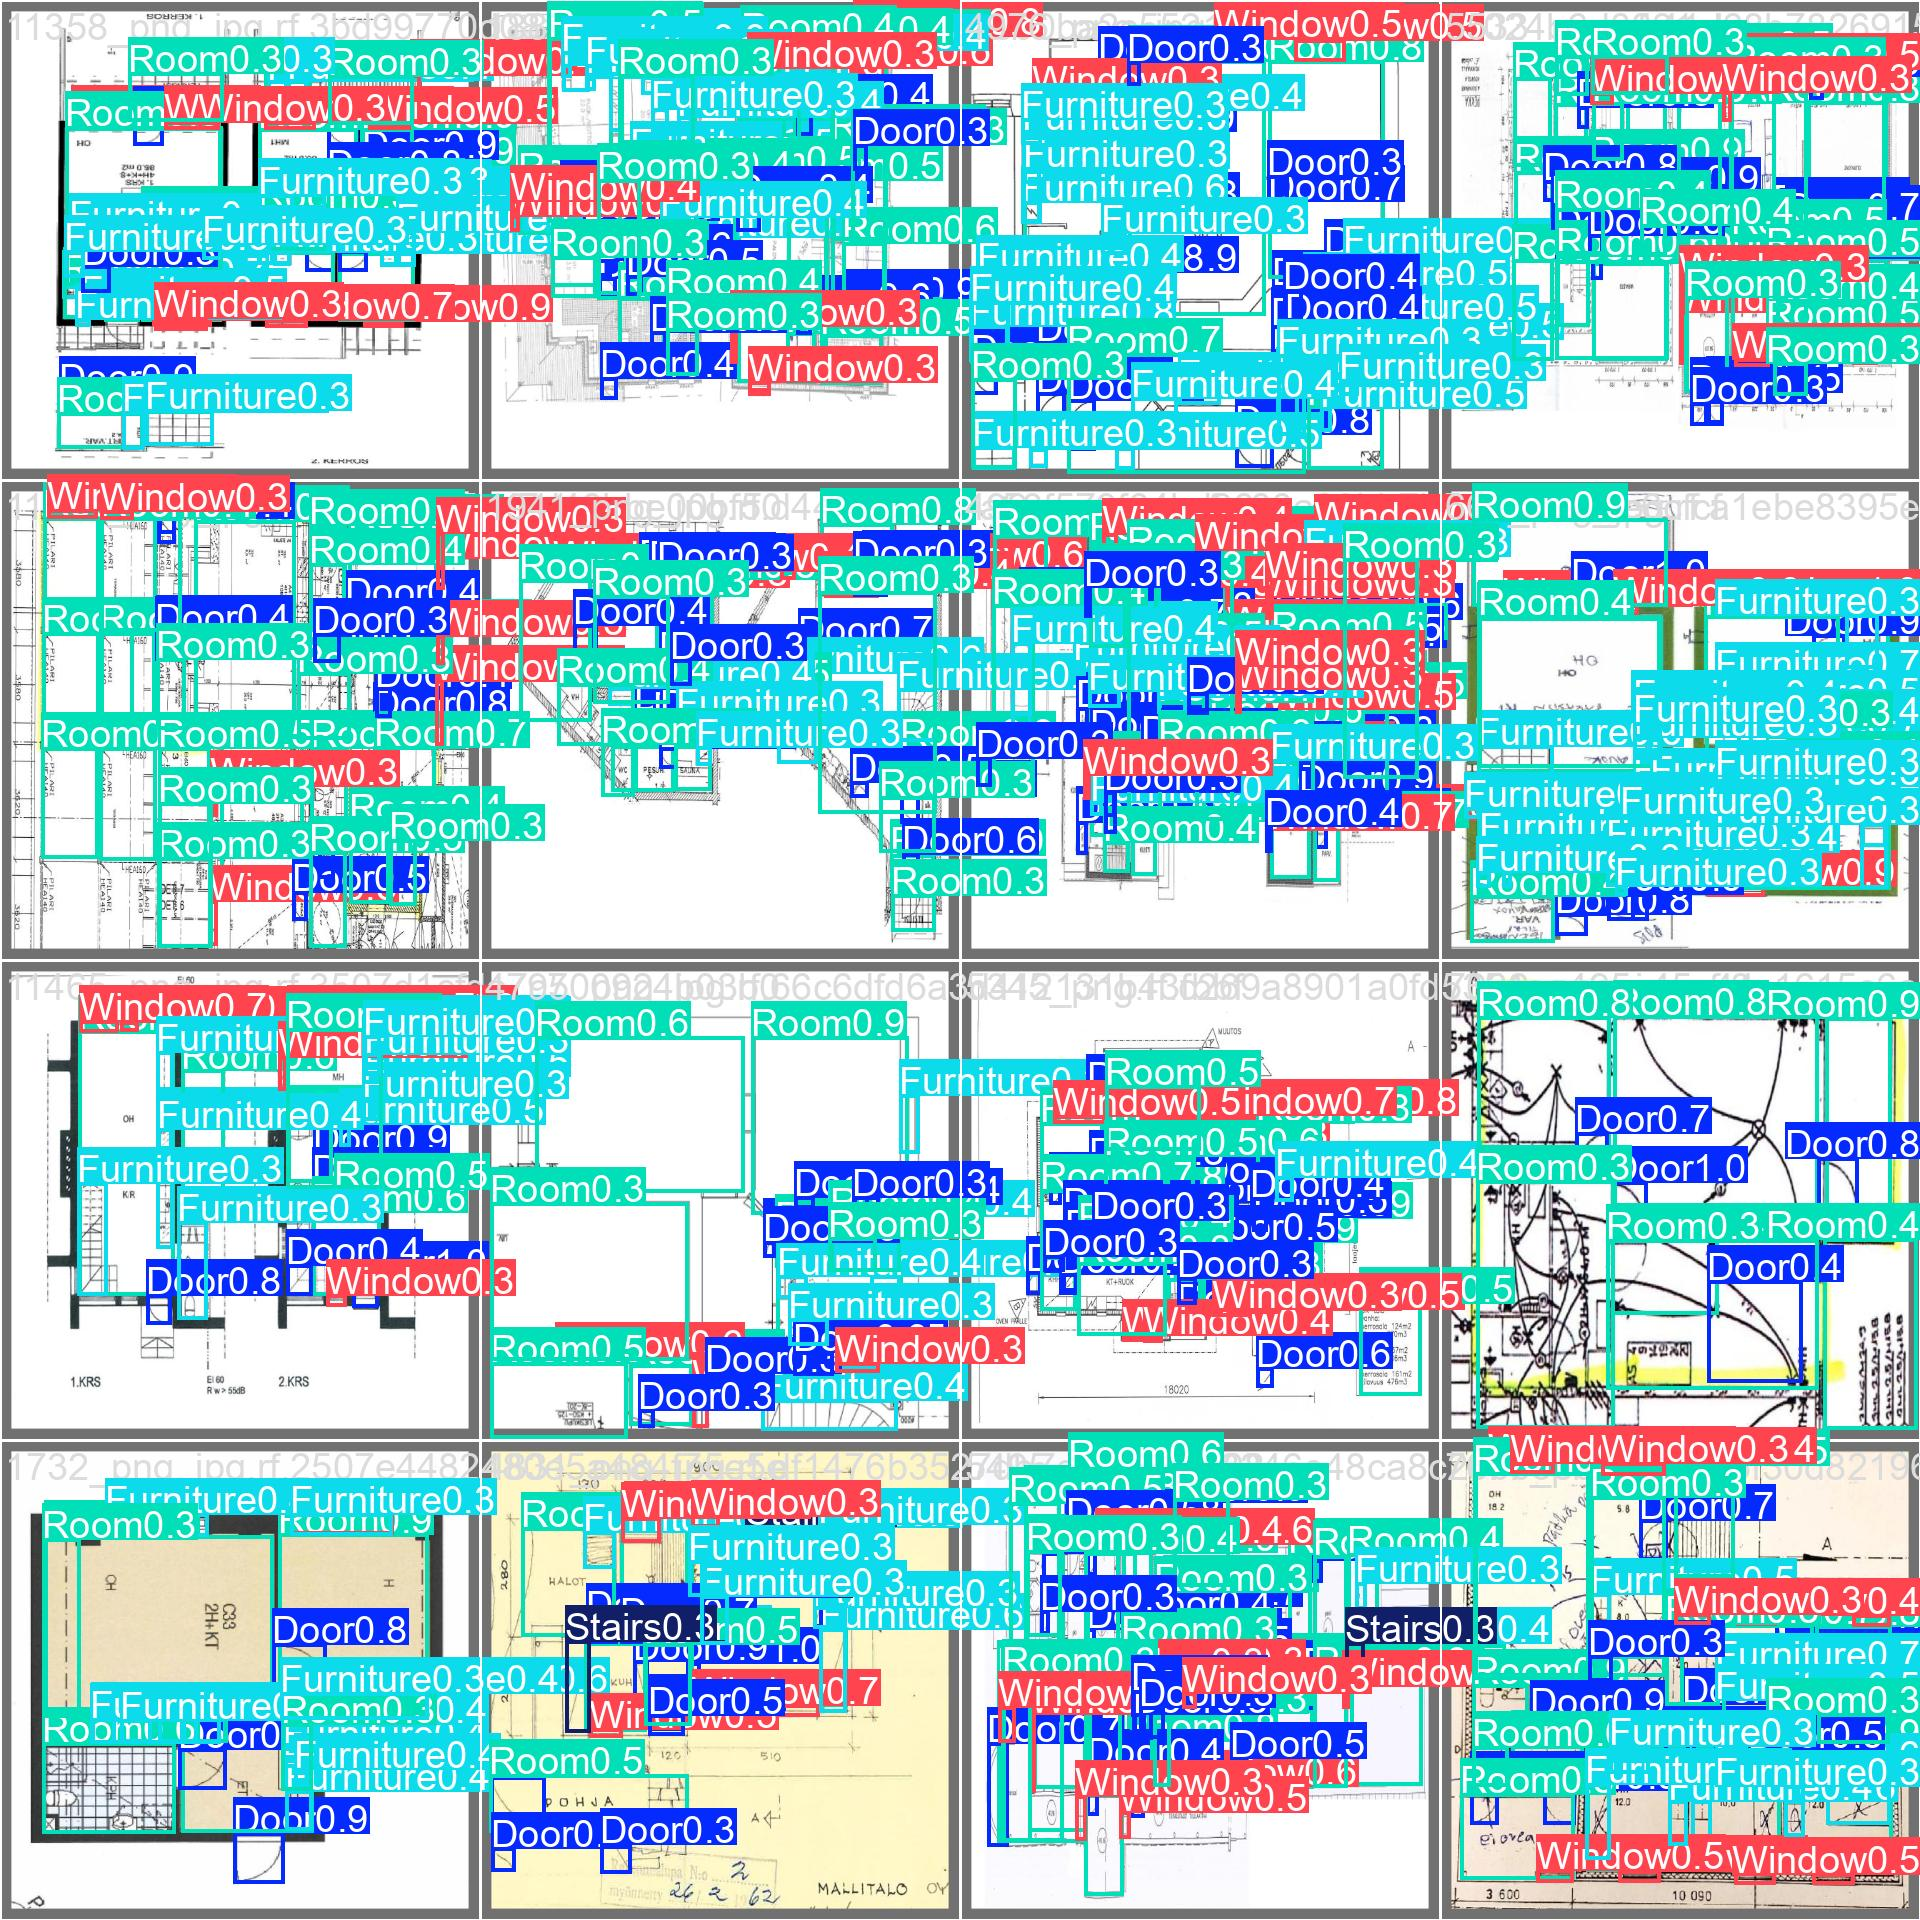

Validation prediction image not found at /content/runs/detect/runs/train/exp-2/val_batch1_pred.jpg

--- Other important files in /content/runs/detect/runs/train/exp-2 ---
Important generated files:
- results.csv
- BoxR_curve.png
- train_batch1.jpg
- confusion_matrix_normalized.png
- train_batch240.jpg
- train_batch242.jpg
- results.png
- BoxPR_curve.png
- BoxP_curve.png
- confusion_matrix.png
- labels.jpg
- train_batch2.jpg
- val_batch0_labels.jpg
- val_batch0_pred.jpg
- train_batch0.jpg
- BoxF1_curve.png
- train_batch241.jpg
- args.yaml
- weights/best.pt
- weights/last.pt

To perform object detection on custom images using the trained model,
you would use the `detect` mode with the generated weights.
The best trained weights are saved in: /content/runs/detect/runs/train/exp-2/weights/best.pt


In [4]:
import argparse
import hashlib
import os
import shutil
import sys
import zipfile
import glob


# ============================================================
# CONFIG
# ============================================================

# Extracted from:
# https://drive.google.com/file/d/1iVq3qa_xrTHb422iZmxqrK1AS8E2h0La/view?usp=sharing
GOOGLE_DRIVE_FILE_ID = "1iVq3qa_xrTHb422iZmxqrK1AS8E2h0La"

# OPTIONAL BUT RECOMMENDED: after your first successful download, this
# script prints the SHA256 checksum of the dataset zip. Paste it here so
# every future download (yours or anyone else's) is automatically checked
# against it -- guaranteeing everyone trains on the exact same data.
# Leave empty to skip verification (the checksum is still printed).
EXPECTED_SHA256 = ""

DATASET_DIR = "dataset"
ZIP_NAME = "dataset_download.zip"
CHECKSUM_FILE = os.path.join(DATASET_DIR, "CHECKSUM.sha256")


# ============================================================
# DATASET DOWNLOAD + INTEGRITY CHECK
# ============================================================

def ensure_gdown_installed():
    try:
        import gdown  # noqa: F401
    except ImportError:
        print("Installing missing dependency 'gdown' ...")
        os.system(f"{sys.executable} -m pip install gdown --quiet")


def compute_sha256(filepath, chunk_size=1024 * 1024):
    """Compute the SHA256 checksum of a file, reading it in chunks so large
    dataset zips don't need to be loaded into memory all at once."""
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            sha256.update(chunk)
    return sha256.hexdigest()


def dataset_already_present():
    """Basic check: does the dataset folder already have images in it?"""
    if not os.path.isdir(DATASET_DIR):
        return False
    for _root, _dirs, files in os.walk(DATASET_DIR):
        if any(f.lower().endswith((".jpg", ".jpeg", ".png")) for f in files):
            return True
    return False


def download_and_extract():
    """Downloads the dataset zip from Google Drive, verifies its SHA256
    checksum, then extracts it into ./dataset/."""
    import gdown

    if GOOGLE_DRIVE_FILE_ID in ("", "PASTE_YOUR_FILE_ID_HERE"):
        print(
            "\n[!] No Google Drive file ID has been set.\n"
            "    Set GOOGLE_DRIVE_FILE_ID near the top of this file.\n"
        )
        sys.exit(1)

    print("Downloading dataset from Google Drive ... (this can take a while for large files)")
    url = f"https://drive.google.com/uc?id={GOOGLE_DRIVE_FILE_ID}"
    gdown.download(url, ZIP_NAME, quiet=False)

    # --- Checksum: proves the file you just got is byte-for-byte the same
    # file that was originally uploaded / trained on ---
    print("Computing SHA256 checksum ...")
    actual_checksum = compute_sha256(ZIP_NAME)
    print(f"SHA256: {actual_checksum}")

    if EXPECTED_SHA256:
        if actual_checksum.lower() == EXPECTED_SHA256.lower():
            print("Checksum verified -- file matches the expected dataset exactly.")
        else:
            os.remove(ZIP_NAME)
            print(
                "\n[!] CHECKSUM MISMATCH!\n"
                f"    Expected: {EXPECTED_SHA256}\n"
                f"    Got:      {actual_checksum}\n"
                "    The downloaded file does NOT match the dataset this project "
                "was trained on.\n"
                "    This can happen if the Google Drive file was changed/replaced, "
                "or the\n    download was corrupted. The partial download has been "
                "deleted. Aborting.\n"
            )
            sys.exit(1)
    else:
        print(
            "No EXPECTED_SHA256 set yet -- skipping verification.\n"
            "Tip: paste the checksum above into EXPECTED_SHA256 in this file "
            "so future downloads are automatically verified."
        )

    print("Extracting dataset ...")
    with zipfile.ZipFile(ZIP_NAME, "r") as zip_ref:
        zip_ref.extractall(".")

    os.remove(ZIP_NAME)

    # If the zip contained a single top-level folder that isn't named
    # "dataset", rename/move it so it matches data.yaml's expectations.
    if not os.path.isdir(DATASET_DIR):
        extracted_items = [
            f for f in os.listdir(".")
            if f not in (ZIP_NAME,) and not f.startswith(".")
        ]
        candidates = [f for f in extracted_items if os.path.isdir(f)]
        if len(candidates) == 1:
            shutil.move(candidates[0], DATASET_DIR)

    # Save the checksum alongside the dataset so anyone can verify by hand later.
    if os.path.isdir(DATASET_DIR):
        with open(CHECKSUM_FILE, "w") as f:
            f.write(f"{actual_checksum}  {ZIP_NAME}\n")

    print(f"\nDone. Dataset is ready in ./{DATASET_DIR}/")
    print(f"Checksum recorded in {CHECKSUM_FILE}\n")


def run_download_mode():
    ensure_gdown_installed()
    if dataset_already_present():
        print(f"Dataset already found in ./{DATASET_DIR}/ -- skipping download.")
        return
    download_and_extract()


# ============================================================
# TRAINING
# ============================================================

def run_train_mode(args):
    from ultralytics import YOLO
    from IPython.display import Image, display

    # Auto-fetch the dataset if it isn't on disk yet.
    if not dataset_already_present():
        print("Dataset not found locally -- fetching it from Google Drive automatically...")
        ensure_gdown_installed()
        download_and_extract()

    model = YOLO(args.model)

    # The model.train() method returns a Trainer object that contains the save_dir.
    trained_model = model.train(
        data=args.data,
        epochs=args.epochs,
        imgsz=args.imgsz,
        batch=args.batch,
        device=args.device if args.device else None,
        project=args.project or "runs/train",
        name=args.name,
        plots=True, # Ensure plots are generated
    )

    metrics = model.val()
    print("Validation results:", metrics)

    # --- Display training results images ---
    print("\n--- Displaying Training Results and Example Validation Predictions ---")

    # Get the actual directory where results were saved
    training_output_dir = str(trained_model.save_dir)

    print(f"Results are saved in: {training_output_dir}")

    # Display training plots (e.g., results.png)
    plots_path = os.path.join(training_output_dir, "results.png")
    if os.path.exists(plots_path):
        print("\nTraining performance plots (results.png):")
        display(Image(filename=plots_path, width=800))
    else:
        print(f"Training plots not found at {plots_path}")

    # Display an example validation batch prediction image (e.g., val_batch0_pred.jpg)
    val_pred_image_path = os.path.join(training_output_dir, "val_batch0_pred.jpg")
    if os.path.exists(val_pred_image_path):
        print("\nExample validation predictions (val_batch0_pred.jpg):")
        display(Image(filename=val_pred_image_path, width=800))
    else:
        print(f"Validation prediction image not found at {val_pred_image_path}")

    # Display another example (e.g., val_batch1_pred.jpg) if it exists
    val_pred_image_path_1 = os.path.join(training_output_dir, "val_batch1_pred.jpg")
    if os.path.exists(val_pred_image_path_1):
        print("\nAnother example validation predictions (val_batch1_pred.jpg):")
        display(Image(filename=val_pred_image_path_1, width=800))
    else:
        print(f"Validation prediction image not found at {val_pred_image_path_1}")

    # List other relevant output files
    print(f"\n--- Other important files in {training_output_dir} ---")
    output_files = glob.glob(os.path.join(training_output_dir, "**/*"), recursive=True)
    important_files = []
    for f in output_files:
        if os.path.isfile(f) and (f.endswith((".pt", ".yaml", ".json", ".csv", ".txt", ".png", ".jpg")) or "confusion_matrix" in f):
            important_files.append(f)
    if important_files:
        print("Important generated files:")
        for f in important_files:
            print(f"- {f.replace(training_output_dir + os.sep, '')}")
    else:
        print("No other important files found.")


    print("\nTo perform object detection on custom images using the trained model,")
    print("you would use the `detect` mode with the generated weights.")
    print(f"The best trained weights are saved in: {os.path.join(training_output_dir, 'weights', 'best.pt')}")


# ============================================================
# INFERENCE
# ============================================================

def run_detect_mode(args):
    from ultralytics import YOLO

    if not args.source:
        print("[!] --source is required in detect mode, e.g:\n"
              "    python main.py --mode detect --source path/to/image_or_folder")
        sys.exit(1)

    weights = args.weights
    if not weights:
        default_best = os.path.join("runs", "train", args.name, "weights", "best.pt")
        weights = default_best if os.path.exists(default_best) else args.model

    model = YOLO(weights)

    results = model.predict(
        source=args.source,
        conf=args.conf,
        save=True,
        project=args.project or "runs/detect",
        name=args.name,
    )

    for r in results:
        print(f"Detections: {len(r.boxes)} objects found in {r.path}")


# ============================================================
# CLI
# ============================================================

def parse_args():
    parser = argparse.ArgumentParser(description="YOLOv11 all-in-one pipeline")
    parser.add_argument(
        "--mode", choices=["download", "train", "detect"], default="train",
        help="'download': only fetch+verify the dataset. 'train' (default): "
             "download if needed, then train. 'detect': run inference."
    )

    # Shared / training args
    parser.add_argument("--data", type=str, default="data.yaml", help="Path to dataset YAML")
    parser.add_argument(
        "--model", type=str, default="yolo11n.pt",
        help="Base model for training (yolo11n/s/m/l/x.pt), or fallback weights for detect"
    )
    parser.add_argument("--epochs", type=int, default=50, help="Training epochs")
    parser.add_argument("--imgsz", type=int, default=640, help="Image size")
    parser.add_argument("--batch", type=int, default=16, help="Batch size")
    parser.add_argument("--device", type=str, default="", help="'', '0', '0,1', or 'cpu'")
    parser.add_argument("--project", type=str, default=None, help="Output folder")
    parser.add_argument("--name", type=str, default="exp", help="Name of this run")

    # Detect-only args
    parser.add_argument("--weights", type=str, default=None,
                         help="Trained weights for detect mode (defaults to runs/train/<name>/weights/best.pt)")
    parser.add_argument("--source", type=str, default=None,
                         help="Image, folder, video, or 0 for webcam (required for detect mode)")
    parser.add_argument("--conf", type=float, default=0.25, help="Confidence threshold for detect mode")

    # In interactive environments like Colab, sometimes extra arguments are passed
    # by the kernel which are not defined by the user. parse_known_args()
    # allows us to ignore these.
    args, unknown = parser.parse_known_args()
    if unknown:
        print(f"Warning: Unknown arguments ignored: {unknown}")
    return args


def main():
    args = parse_args()

    if args.mode == "download":
        run_download_mode()
    elif args.mode == "train":
        run_train_mode(args)
    elif args.mode == "detect":
        run_detect_mode(args)


if __name__ == "__main__":
    main()